#Enviroment preparation

In [ ]:
pip install scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal
import seaborn as sns
# %matplotlib inline

#Dataset Load

In [ ]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/AniShpiz/ML1/refs/heads/main/dataset_sentiment.csv")

# a copy for future use (comparison, etc.)
df_original = df.copy()

In [ ]:
df.head()

,credibility_impact,zoomer_energy,drama_score,marketing_score,bad_words,ptod_Morning,has_profile_picture,cm_gold,cm_grey,cm_none,previous_posts_count,sentiment_numeric
0,0.0,2.488367,56.0,0.000000,1,False,1,False,False,True,144,-1
1,0.0,0.000000,50.0,0.000000,0,True,0,False,False,True,0,1
2,0.0,4.510860,56.0,0.000000,0,True,1,False,False,True,90,1
3,0.0,0.000000,28.0,0.000000,0,False,1,False,False,False,0,-1
4,0.0,3.912023,118.5,0.013453,1,False,1,False,False,True,49,-1


#Split dataset to train and test

In [ ]:
# preform a train test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=['sentiment_numeric'])
y = df['sentiment_numeric']

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=42) # 80 / 20 split
print("Train label percentages\n-----------\n", (pd.value_counts(y_train)/y_train.shape[0])*100)
print("\nTest label percentages\n-----------\n", pd.value_counts(y_test)/y_test.shape[0]*100)

Train label percentages
-----------
 sentiment_numeric
-1    56.308189
 1    43.691811
Name: count, dtype: float64

Test label percentages
-----------
 sentiment_numeric
-1    57.048765
 1    42.951235
Name: count, dtype: float64


/tmp/ipython-input-5-2748450120.py:8: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print("Train label percentages\n-----------\n", (pd.value_counts(y_train)/y_train.shape[0])*100)
/tmp/ipython-input-5-2748450120.py:9: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print("\nTest label percentages\n-----------\n", pd.value_counts(y_test)/y_test.shape[0]*100)


In [ ]:
len(X_train)

31578

In [ ]:
len(X_test)

7895

In [ ]:
len(X_test)+len(X_train)

39473

#Training

## Decision tree (DT)

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree # for training and ploting DT
from sklearn.metrics import accuracy_score # for evaluation of the model using accuracy metric

In [ ]:
class_names = ['Negative', 'Positive']

In [ ]:
model = DecisionTreeClassifier(max_depth=9, # we limit the depth after tuning this hyperparameter
                               criterion='entropy', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=9, random_state=42)

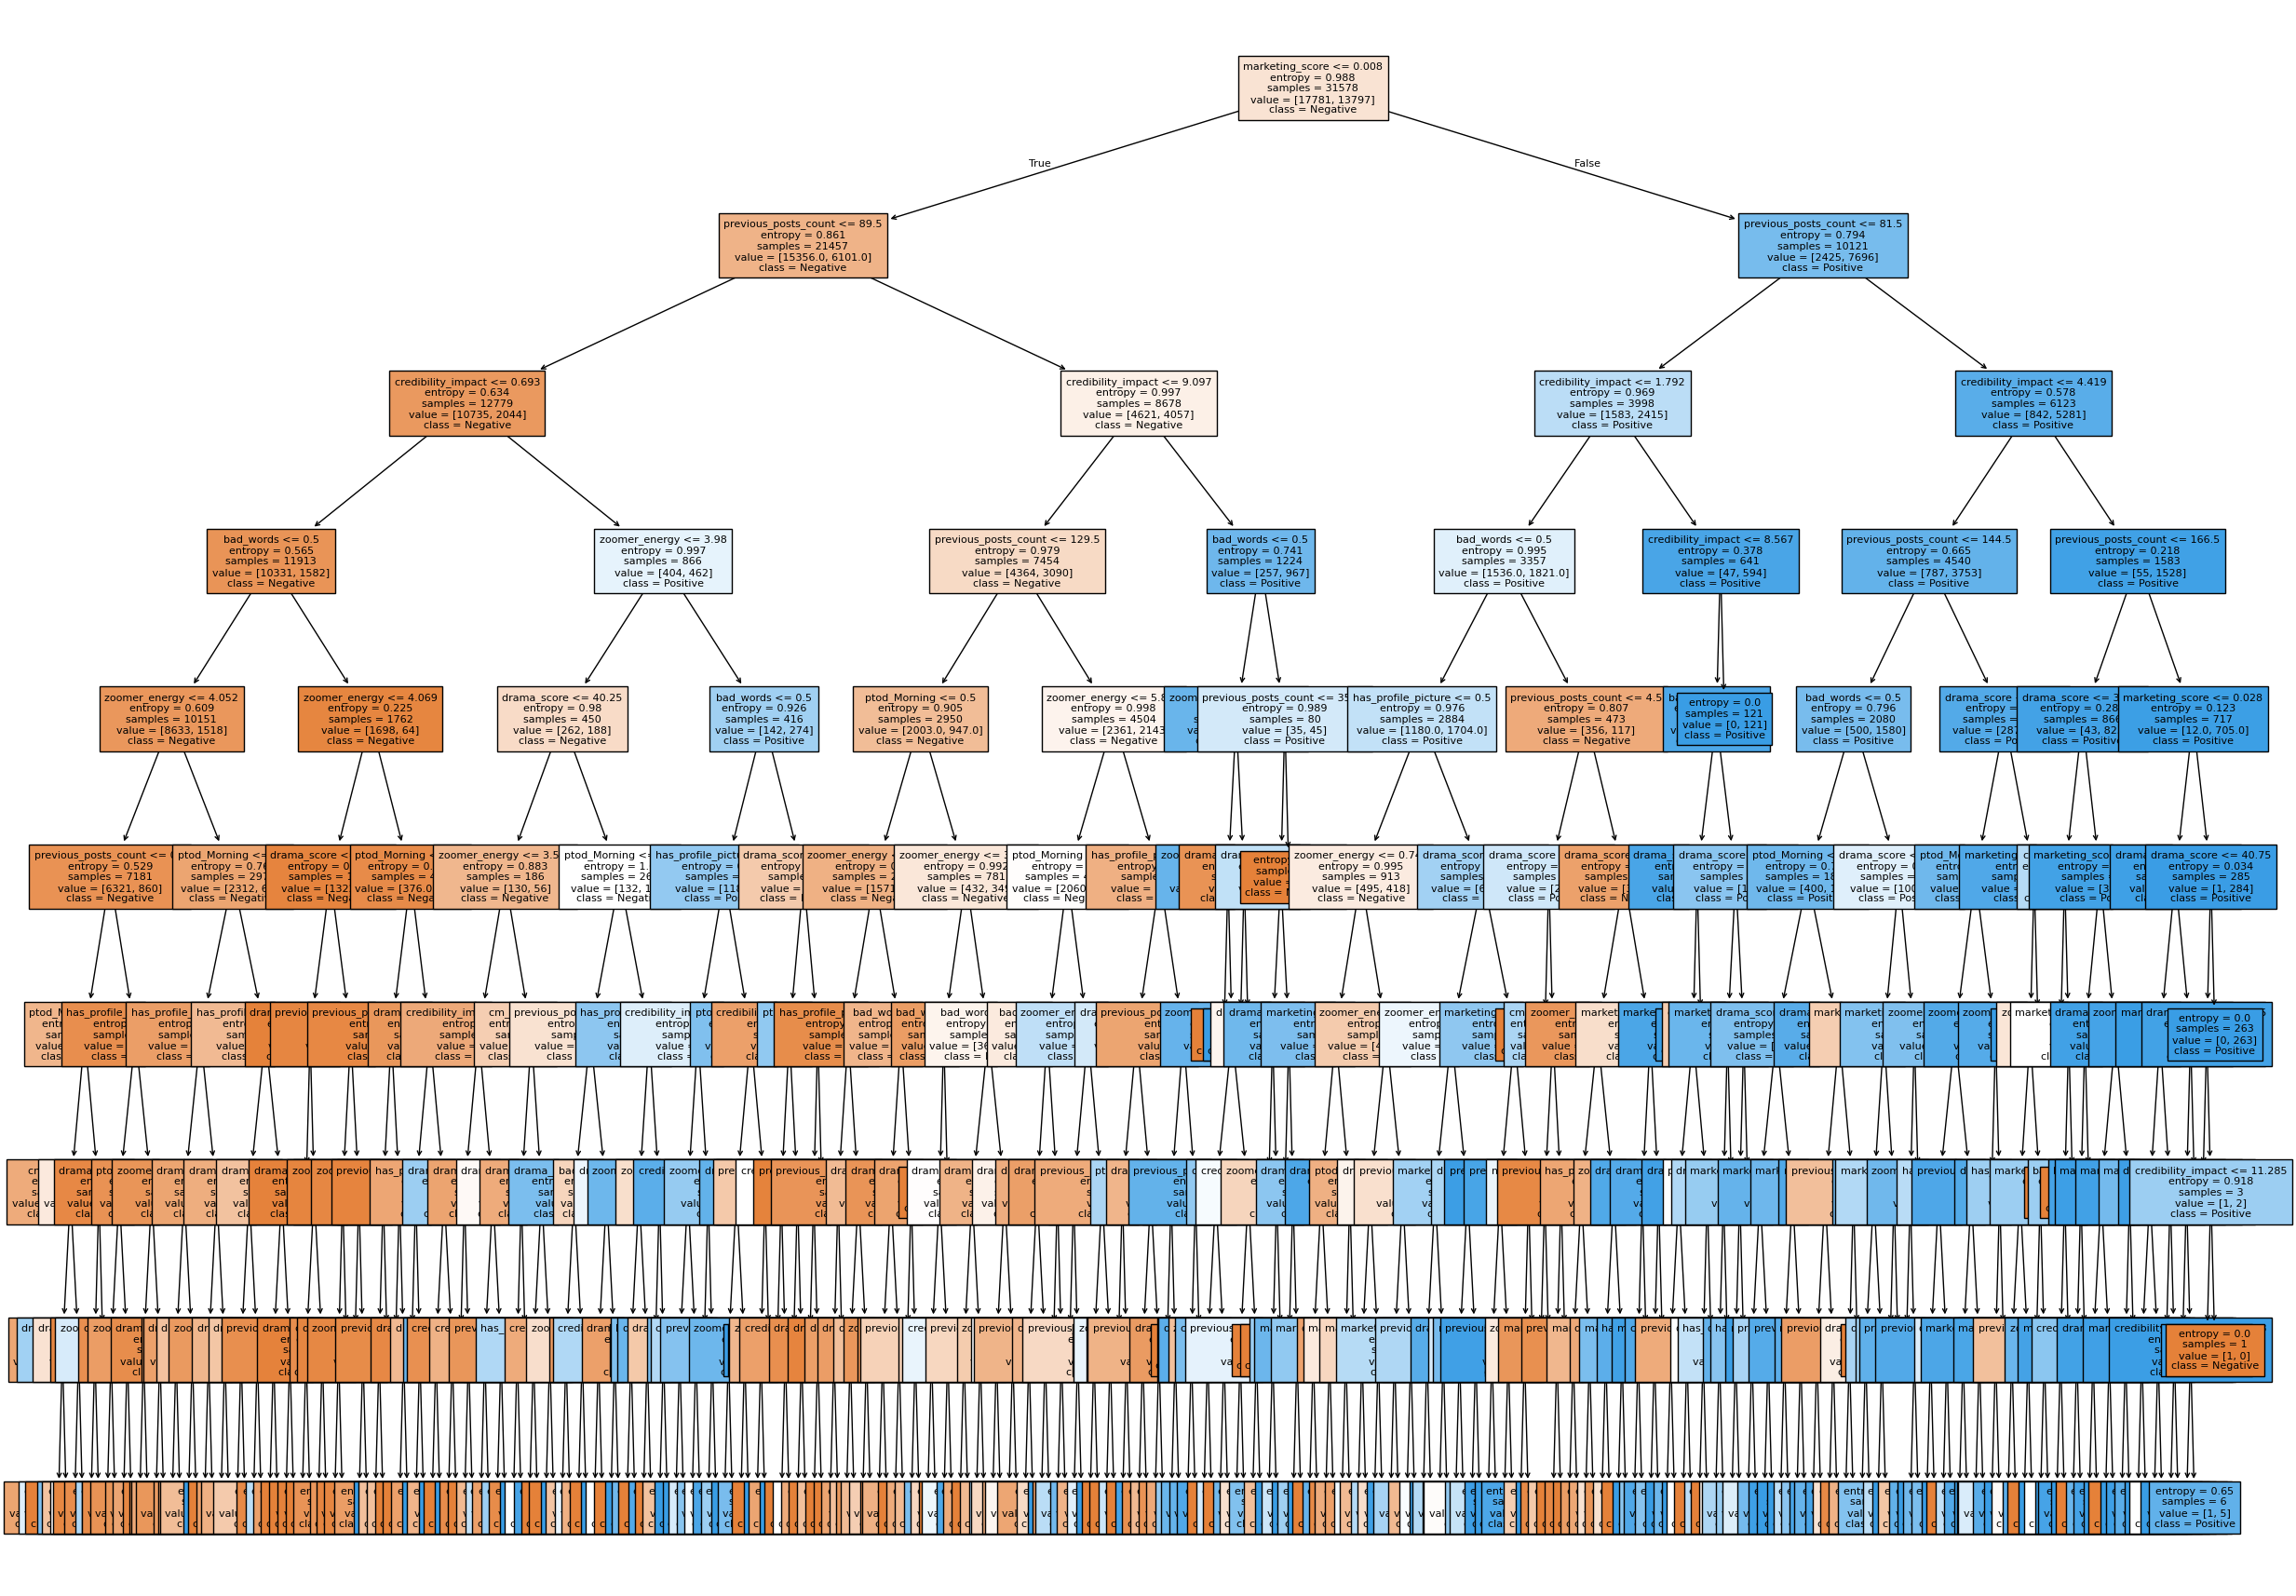

In [ ]:
# plot the new tree
plt.figure(figsize=(30, 22))
plot_tree(model, filled=True,class_names=class_names, feature_names=X_train.columns.to_list(), fontsize=8)
plt.show()

In [ ]:
# lets look at the change in accuracy on the train set
print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=model.predict(X_train)):.2f}")

Accuracy: 0.80


### Hyperparameter tuning & Evaluation Methods - Long way (not recommended)


#### Evaluation Method - Holdout-set

In [ ]:
# another option is to split the data in a stratified fashion
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    stratify=y, # note the new parameter here
                                                    test_size=0.2, random_state=42)
print("Train label percentages\n-----------\n", (pd.value_counts(y_train)/y_train.shape[0])*100)
print("\nTest label percentages\n-----------\n", pd.value_counts(y_test)/y_test.shape[0]*100)

Train label percentages
-----------
 sentiment_numeric
-1    56.457027
 1    43.542973
Name: count, dtype: float64

Test label percentages
-----------
 sentiment_numeric
-1    56.453452
 1    43.546548
Name: count, dtype: float64


/tmp/ipython-input-14-724290170.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print("Train label percentages\n-----------\n", (pd.value_counts(y_train)/y_train.shape[0])*100)
/tmp/ipython-input-14-724290170.py:6: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  print("\nTest label percentages\n-----------\n", pd.value_counts(y_test)/y_test.shape[0]*100)


now we have the same balance in the training and test sets

#### Baseline


In [ ]:
# Baseline
model = DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
##training the model over the train set, growing the tree to its full length
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
##predinting on the train set to calculate train acuracy
print(f"Train accuracy: {accuracy_score(y_train, model.predict(X_train)):.2}")

##predinting on the test set to calculate test acuracy
print(f"Test accuracy: {accuracy_score(y_test, model.predict(X_test)):.2}")

Train accuracy: 0.99
Test accuracy: 0.71


In [ ]:
# tune max_depth.
# first we initialize a list of optional depths for the tree.
max_depth_list = np.arange(1, 16, 1)
print('The max depth values we will check are:')
print(max_depth_list)

The max depth values we will check are:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]


In [ ]:
res = list()
for max_depth in max_depth_list: # loop thorugh all parameter values
    model = DecisionTreeClassifier(criterion='entropy',
                                   max_depth=max_depth, # here we pass a different max_depth value each time
                                   random_state=42) # define model
    model.fit(X_train, y_train) # fit model on training data

    # predict and save results
    res.append({'max_depth': max_depth,
                      'train_acc':accuracy_score(y_train, model.predict(X_train)),
                      'test_acc':accuracy_score(y_test, model.predict(X_test))})

res=pd.DataFrame(res)
res

,max_depth,train_acc,test_acc
0,1,0.729685,0.726409
1,2,0.729685,0.726409
2,3,0.754798,0.749335
3,4,0.763918,0.762508
4,5,0.775318,0.761748
5,6,0.781145,0.765421
6,7,0.782760,0.767828
7,8,0.789759,0.764408
8,9,0.797359,0.764788
9,10,0.807683,0.769094


#### What is the optimal depth?

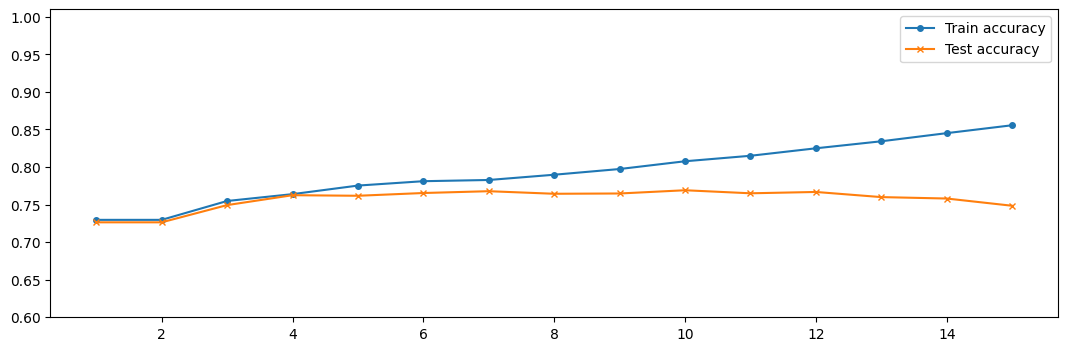

In [ ]:
# Plot train/test accuracy over max depth parameter
plt.figure(figsize=(13, 4))
plt.plot(res['max_depth'], res['train_acc'], marker='o', markersize=4)
plt.plot(res['max_depth'], res['test_acc'], marker='x', markersize=4)
plt.legend(['Train accuracy', 'Test accuracy'])
plt.ylim(0.6,1.01)
plt.show()

In [ ]:
res.sort_values('test_acc', ascending=False)

,max_depth,train_acc,test_acc
9,10,0.807683,0.769094
6,7,0.782760,0.767828
11,12,0.824941,0.766814
5,6,0.781145,0.765421
10,11,0.814998,0.765041
8,9,0.797359,0.764788
7,8,0.789759,0.764408
3,4,0.763918,0.762508
4,5,0.775318,0.761748
12,13,0.834283,0.759975


#### Lets try different split

In [ ]:
# Train-Validation split with different random state
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X, y,stratify=y, test_size=0.3, random_state=99)

In [ ]:
res_2 = []
for max_depth in max_depth_list:
    model = DecisionTreeClassifier(criterion='entropy',
                                   max_depth=max_depth, # here we pass a different max_depth value each time
                                   random_state=42)
    model.fit(X_train_2, y_train_2)
    res_2.append({'max_depth': max_depth,
                      'train_acc':accuracy_score(y_train_2, model.predict(X_train_2)),
                      'val_acc':accuracy_score(y_test_2, model.predict(X_test_2))})

res_2=pd.DataFrame(res_2)

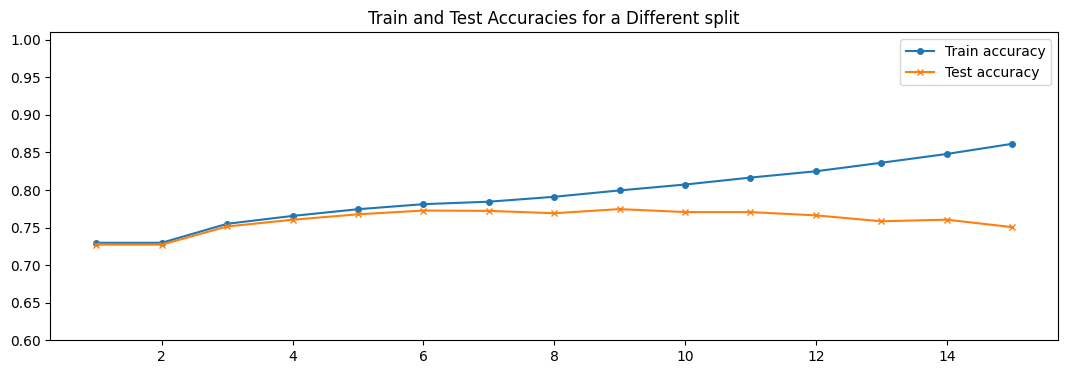

In [ ]:
plt.figure(figsize=(13, 4))
plt.plot(res['max_depth'], res_2['train_acc'], marker='o', markersize=4)
plt.plot(res['max_depth'], res_2['val_acc'], marker='x', markersize=4)
plt.legend(['Train accuracy', 'Test accuracy'])
plt.title('Train and Test Accuracies for a Different split')
plt.ylim(0.6,1.01)
plt.show()

comparing to the prev split (20/80)

In [ ]:
# we now check the best depth and initialize a new model with this depth
best_max_depth = int(res_2.loc[res_2['val_acc'].idxmax(), 'max_depth'])
print("Best tree depth: ", best_max_depth)
best_model = DecisionTreeClassifier(criterion='entropy', max_depth=best_max_depth, random_state=42)

Best tree depth:  9


#### Evaluation Method - KFold cross-validation

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
res = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
    for max_depth in max_depth_list:
        model = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, random_state=42)


        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        preds = model.predict(X_train.iloc[val_idx])
        acc = accuracy_score(y_train.iloc[val_idx], preds)

        res.append({
            'fold': fold + 1,
            'max_depth': max_depth,
            'acc': acc
        })

res = pd.DataFrame(res)


In [ ]:
res

,fold,max_depth,acc
0,1,1,0.717859
1,1,2,0.717859
2,1,3,0.745408
3,1,4,0.755858
4,1,5,0.758233
...,...,...,...
70,5,11,0.777989
71,5,12,0.778306
72,5,13,0.774980
73,5,14,0.763262


lets average per fold

In [ ]:
# calculate the average 'acc' for each 'max_depth' over all the folds, then reset the index and sort from best to worst
average_res=res.groupby(['max_depth'])['acc'].mean().reset_index().sort_values('acc',ascending=False)

In [ ]:
average_res

,max_depth,acc
8,9,0.778644
9,10,0.777915
5,6,0.777218
6,7,0.776205
7,8,0.775540
10,11,0.773988
11,12,0.772183
4,5,0.770537
12,13,0.766895
3,4,0.763190


In [ ]:
best_max_depth = average_res.loc[8,'max_depth']
print("Best tree depth: ", best_max_depth)


Best tree depth:  9


In [ ]:
# define new model with best parameter(s)
model = DecisionTreeClassifier(criterion='entropy',
                               max_depth=best_max_depth, # train model with the best parameter
                               random_state=42)

# train on the whole training set
model.fit(X_train, y_train)

# test on the test set
preds = model.predict(X_test)
print("Test accuracy: ", round(accuracy_score(y_test, preds), 2))

Test accuracy:  0.76


### Adjusting more Hyperparameters (all in one way - recommended)

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
# defining the grid to tune the model
# we will tune: (max_depth, criterion, max_features)
param_grid = {'max_depth': np.arange(1, 16, 1),
              'criterion': ['entropy', 'gini'],
              'max_features': ['sqrt', 'log2', None],
              'min_samples_split': [1, 5, 10],
              'min_samples_leaf': [1, 5, 10],

             }

# lets check the number of combinations
comb = 1
for list_ in param_grid.values():
    comb *= len(list_)
print(f'we have {comb} combinations in total')

we have 810 combinations in total


In [ ]:
##Grid search will perform a 5-fold CV (cv=5)
best_model = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                           param_grid=param_grid,
                           refit=True, # this means the best model will be available to us at the end, refitted on the WHOLE data
                           verbose=1, # if 2, print for each iteration
                           cv=5,
                           scoring='roc_auc') # number of folds

In [ ]:
from time import time
start_time = time()
best_model.fit(X_train,y_train)
print(f'it took us {time()-start_time} seconds to train the model')

Fitting 5 folds for each of 810 candidates, totalling 4050 fits
it took us 133.37649536132812 seconds to train the model


#### Accuarcy using roc_auc

In [ ]:
train_preds = best_model.predict(X_train)
print("Train accuracy: ", round(accuracy_score(y_train, train_preds), 3))

Train accuracy:  0.795


In [ ]:
preds = best_model.predict(X_test)
print("Test accuracy: ", round(accuracy_score(y_test, preds), 3))

Test accuracy:  0.771


In [ ]:
from sklearn.metrics import roc_auc_score

# הסתברויות למחלקה החיובית (במקרה שלנו: sentiment = 1)
train_probs = best_model.predict_proba(X_train)[:, 1]
test_probs = best_model.predict_proba(X_test)[:, 1]

# חישוב AUC
train_auc = roc_auc_score(y_train, train_probs)
test_auc = roc_auc_score(y_test, test_probs)

print("Train AUC-ROC:", round(train_auc, 3))
print("Test AUC-ROC:", round(test_auc, 3))


Train AUC-ROC: 0.878
Test AUC-ROC: 0.852


### Feature importance

                 Feature  Importance
3        marketing_score    0.425832
10  previous_posts_count    0.239452
0     credibility_impact    0.123855
2            drama_score    0.061711
1          zoomer_energy    0.057124
4              bad_words    0.038885
6    has_profile_picture    0.023594
5           ptod_Morning    0.023392
9                cm_none    0.003736
8                cm_grey    0.001405
7                cm_gold    0.001014


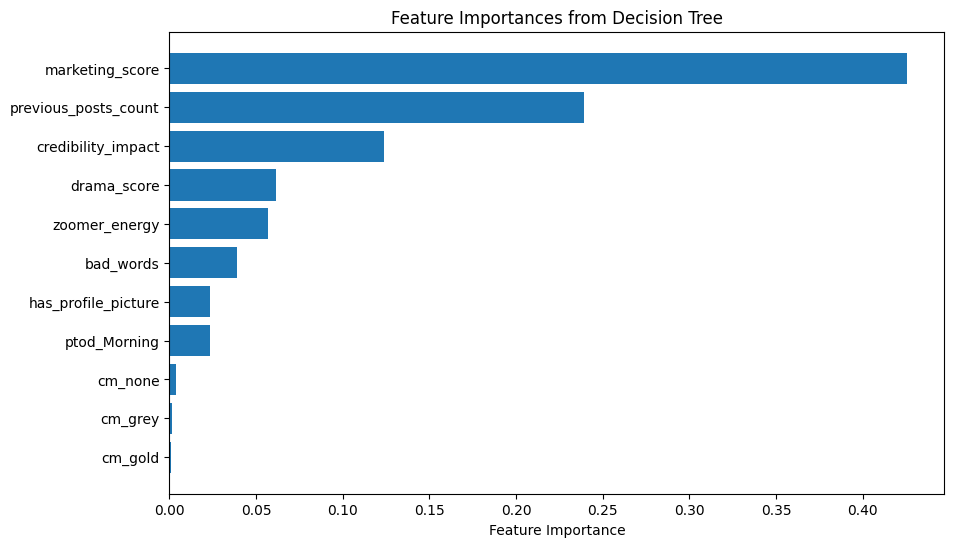

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# קבלת החשיבויות מהמודל המאומן
importances = best_model.best_estimator_.feature_importances_

# התאמה לשמות הפיצ'רים
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# הדפסה
print(feature_importance_df)

# תרשים (לא חובה, אבל יפה לדו"ח)
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('Feature Importances from Decision Tree')
plt.show()


## Artificial Neural Networks (ANN)

### MLP default training

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

MLP is scale sensitive, hence we have to normalize or standardize the input

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

default training

In [ ]:
model = MLPClassifier(random_state=42)

In [ ]:
default_model = MLPClassifier()
for param, value in default_model.get_params().items():
    print(f"{param}: {value}")

activation: relu
alpha: 0.0001
batch_size: auto
beta_1: 0.9
beta_2: 0.999
early_stopping: False
epsilon: 1e-08
hidden_layer_sizes: (100,)
learning_rate: constant
learning_rate_init: 0.001
max_fun: 15000
max_iter: 200
momentum: 0.9
n_iter_no_change: 10
nesterovs_momentum: True
power_t: 0.5
random_state: None
shuffle: True
solver: adam
tol: 0.0001
validation_fraction: 0.1
verbose: False
warm_start: False


In [ ]:
model.fit(X_train_s, y_train)

MLPClassifier(random_state=42)

###Prediction and Evaluation

Train Accuracy: 0.798
Test Accuracy: 0.787
Train AUC-ROC: 0.880
Test AUC-ROC: 0.868
Confusion Matrix:
 [[3816  641]
 [1043 2395]]


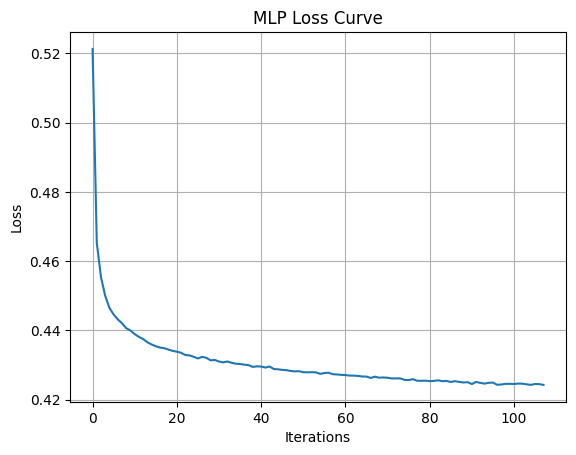

In [ ]:
y_train_pred = model.predict(X_train_s)
y_test_pred = model.predict(X_test_s)

# AUC-ROC
train_auc = roc_auc_score(y_train, model.predict_proba(X_train_s)[:, 1])
test_auc = roc_auc_score(y_test, model.predict_proba(X_test_s)[:, 1])

# (Accuracy)
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.3f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Train AUC-ROC: {train_auc:.3f}")
print(f"Test AUC-ROC: {test_auc:.3f}")

# Confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

# Loss curve
plt.plot(model.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Loss Curve")
plt.grid(True)
plt.show()

### Hyperparameters Tuning

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (150,), (100, 100)],
    'activation': ['relu', 'logistic']
}

mlp = MLPClassifier(max_iter=200, random_state=42)

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    verbose=2
)

# lets check the number of combinations
comb = 1
for list_ in param_grid.values():
    comb *= len(list_)
print(f'we have {comb} combinations in total')


we have 8 combinations in total


🚸 ALERT: remove the comment sign below (#) if you want to train the ANN (it's in a comment cause the training takes some time.... (20-30min~)

In [ ]:
grid_search.fit(X_train_s, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END ..........activation=relu, hidden_layer_sizes=(50,); total time=  11.7s
[CV] END ..........activation=relu, hidden_layer_sizes=(50,); total time=   8.2s
[CV] END ..........activation=relu, hidden_layer_sizes=(50,); total time=   9.3s
[CV] END ..........activation=relu, hidden_layer_sizes=(50,); total time=   9.3s
[CV] END ..........activation=relu, hidden_layer_sizes=(50,); total time=   8.4s
[CV] END .........activation=relu, hidden_layer_sizes=(100,); total time=  13.5s
[CV] END .........activation=relu, hidden_layer_sizes=(100,); total time=  13.5s
[CV] END .........activation=relu, hidden_layer_sizes=(100,); total time=  14.3s
[CV] END .........activation=relu, hidden_layer_sizes=(100,); total time=  13.4s
[CV] END .........activation=relu, hidden_layer_sizes=(100,); total time=  12.0s
[CV] END .........activation=relu, hidden_layer_sizes=(150,); total time=  23.2s
[CV] END .........activation=relu, hidden_layer_s

GridSearchCV(cv=5, estimator=MLPClassifier(random_state=42),
             param_grid={'activation': ['relu', 'logistic'],
                         'hidden_layer_sizes': [(50,), (100,), (150,),
                                                (100, 100)]},
             return_train_score=True, scoring='accuracy', verbose=2)

#### Summary table for best-model decision

In [ ]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)

def parse_layers(tpl):
    return len(tpl), list(tpl)

results[['Hidden Layers', 'Neurons per Layer']] = results['param_hidden_layer_sizes'].apply(
    lambda x: pd.Series(parse_layers(x))
)

summary = results[[
    'Hidden Layers',
    'Neurons per Layer',
    'param_activation',
    'mean_train_score',
    'mean_test_score'
]].rename(columns={
    'param_activation': 'Activation Function',
    'mean_train_score': 'Train Accuracy',
    'mean_test_score': 'Validation Accuracy'
})

summary['Train Accuracy'] = summary['Train Accuracy'].round(3)
summary['Validation Accuracy'] = summary['Validation Accuracy'].round(3)

summary = summary.sort_values(by=['Validation Accuracy'], ascending=False).reset_index(drop=True)


print(summary.to_string(index=True))


   Hidden Layers Neurons per Layer Activation Function  Train Accuracy  Validation Accuracy
0              1             [150]            logistic           0.795                0.793
1              2        [100, 100]            logistic           0.795                0.792
2              1              [50]            logistic           0.795                0.792
3              1             [100]            logistic           0.794                0.792
4              1             [150]                relu           0.801                0.791
5              1              [50]                relu           0.798                0.791
6              1             [100]                relu           0.800                0.790
7              2        [100, 100]                relu           0.811                0.789


#### Save the best-model

In [ ]:
best_model = grid_search.best_estimator_

In [ ]:
best_model

MLPClassifier(activation='logistic', hidden_layer_sizes=(150,), random_state=42)

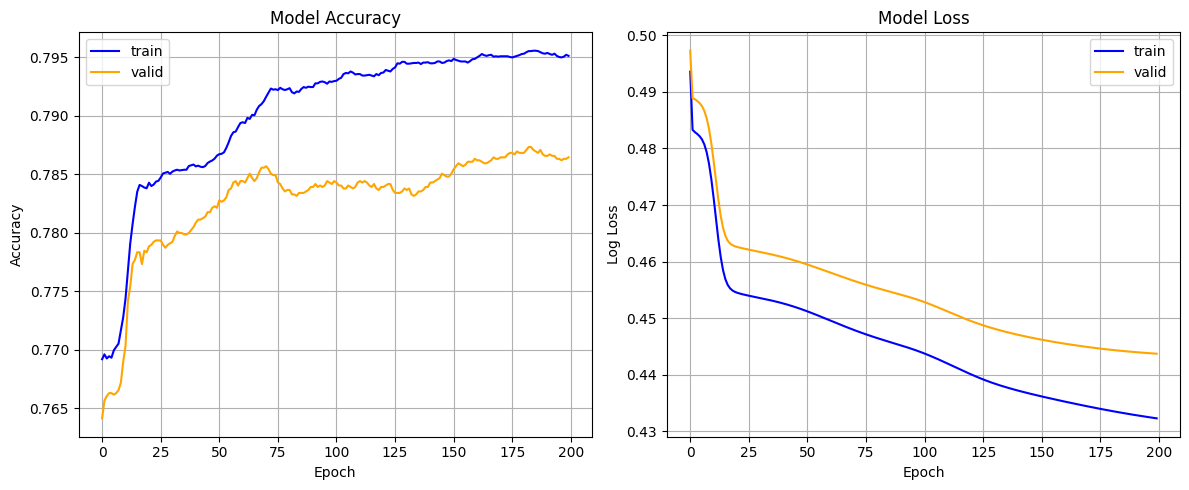

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt

train_acc = []
val_acc = []
train_loss = []
val_loss = []

best_params = grid_search.best_params_

model = MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    activation=best_params['activation'],
    max_iter=1,
    warm_start=True,
    random_state=42
)

epochs = 200
for epoch in range(epochs):
    model.fit(X_train_s, y_train)

    # תחזיות והפסדים
    y_train_pred_proba = model.predict_proba(X_train_s)
    y_val_pred_proba = model.predict_proba(X_test_s)

    train_acc.append(model.score(X_train_s, y_train))
    val_acc.append(model.score(X_test_s, y_test))

    train_loss.append(log_loss(y_train, y_train_pred_proba))
    val_loss.append(log_loss(y_test, y_val_pred_proba))

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='train', color='blue')
plt.plot(val_acc, label='valid', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='train', color='blue')
plt.plot(val_loss, label='valid', color='orange')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## SVM

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
%matplotlib inline

training

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC


scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
svm = LinearSVC(dual=False, max_iter=10000, random_state=42)

grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_s, y_train)

'''
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

svm = SVC(kernel='linear')

# GridSearchCV
grid = GridSearchCV(svm, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train_s, y_train)
'''
best_svm = grid.best_estimator_

y_train_pred = best_svm.predict(X_train_s)
y_test_pred = best_svm.predict(X_test_s)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

weights = best_svm.coef_[0]
features = X_train.columns
weights_df = pd.DataFrame({'Feature': features, 'Weight': weights})
weights_df['AbsWeight'] = weights_df['Weight'].abs()
weights_df = weights_df.sort_values(by='AbsWeight', ascending=False)

print("\nLinear Decision Function:")
equation = " + ".join([f"{round(w, 3)}·{f}" for f, w in zip(features, weights)])
print(f"f(x) = {equation} + {round(best_svm.intercept_[0], 3)}")

print("\nFeature Importances (by absolute weight):")
print(weights_df[['Feature', 'Weight']])


Train Accuracy: 0.769
Test Accuracy: 0.767

Linear Decision Function:
f(x) = -0.04·credibility_impact + 0.046·zoomer_energy + 0.157·drama_score + 0.33·marketing_score + -0.139·bad_words + 0.108·ptod_Morning + 0.056·has_profile_picture + 0.203·cm_gold + 0.211·cm_grey + 0.0·cm_none + 0.187·previous_posts_count + -0.116

Feature Importances (by absolute weight):
                 Feature    Weight
3        marketing_score  0.330102
8                cm_grey  0.210992
7                cm_gold  0.202773
10  previous_posts_count  0.186788
2            drama_score  0.157188
4              bad_words -0.138518
5           ptod_Morning  0.107799
6    has_profile_picture  0.056490
1          zoomer_energy  0.046192
0     credibility_impact -0.040360
9                cm_none  0.000242


## K-Means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [ ]:
selected_features = [
    'marketing_score',
    'drama_score',
    'credibility_impact',
    'previous_posts_count'
]

X_clustering = df[selected_features]


In [ ]:
#from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)


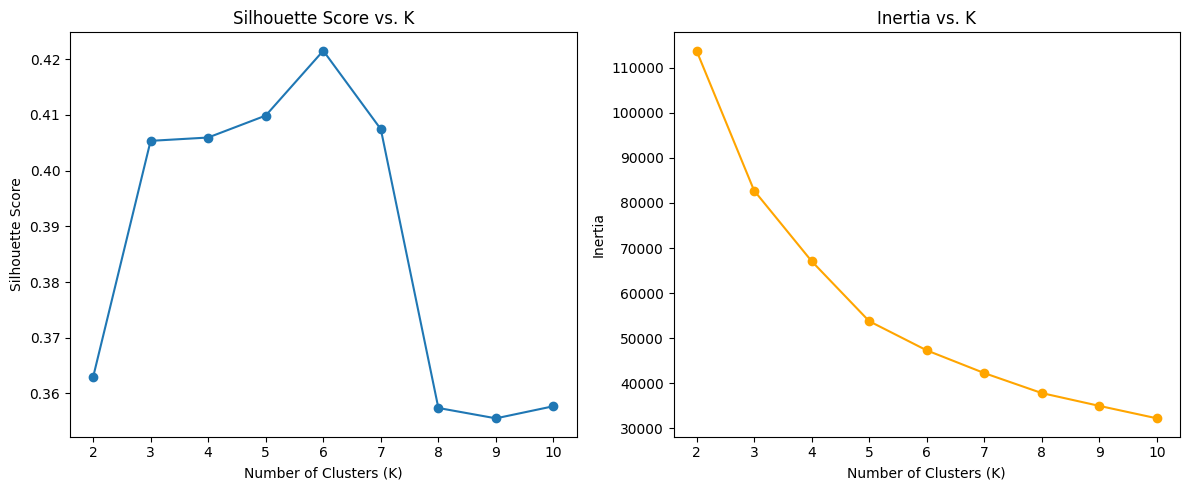

In [ ]:


# שלב 2: הרצת KMeans לערכים שונים של K
k_values = range(2, 11)
silhouette_scores = []
inertias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    inertias.append(kmeans.inertia_)

# שלב 3: גרף השוואה בין K לערכים
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, silhouette_scores, marker='o')
plt.title('Silhouette Score vs. K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.subplot(1, 2, 2)
plt.plot(k_values, inertias, marker='o', color='orange')
plt.title('Inertia vs. K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.tight_layout()
plt.show()


lets choose K = 6

In [ ]:
final_k = 6

In [ ]:
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

comparison = pd.DataFrame({'Cluster': cluster_labels, 'Sentiment': y})
crosstab = pd.crosstab(comparison['Cluster'], comparison['Sentiment'])

print("Cross Tabulation between Clusters and Sentiment:")
print(crosstab)


Cross Tabulation between Clusters and Sentiment:
Sentiment     -1     1
Cluster               
0           3553  3040
1          14022  3368
2           1901  4149
3            141  2598
4            775  1743
5           1893  2290


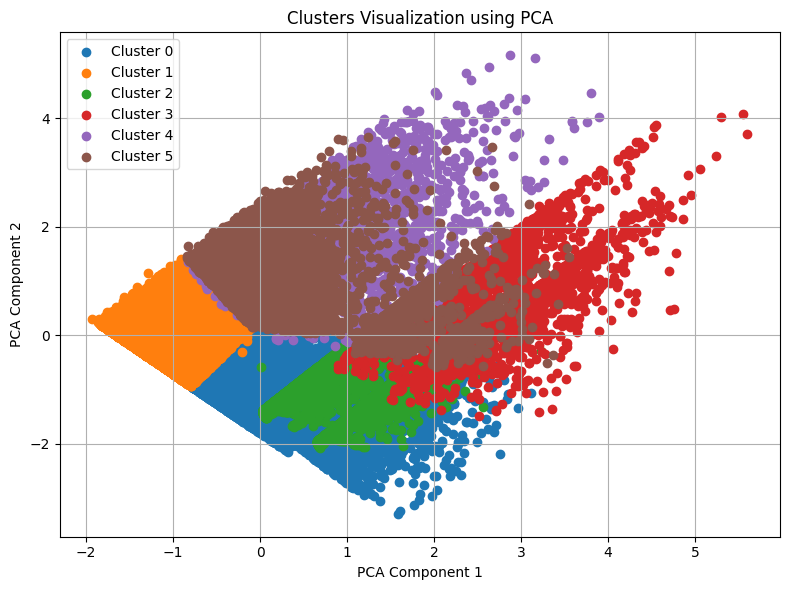

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


k = final_k

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(X_pca[cluster_labels == i, 0], X_pca[cluster_labels == i, 1], label=f"Cluster {i}")

plt.title("Clusters Visualization using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Evaluation

here we are choosing MLP due to its best measurments so far

In [ ]:
best_model

MLPClassifier(activation='logistic', hidden_layer_sizes=(150,), random_state=42)

##ROC Plot

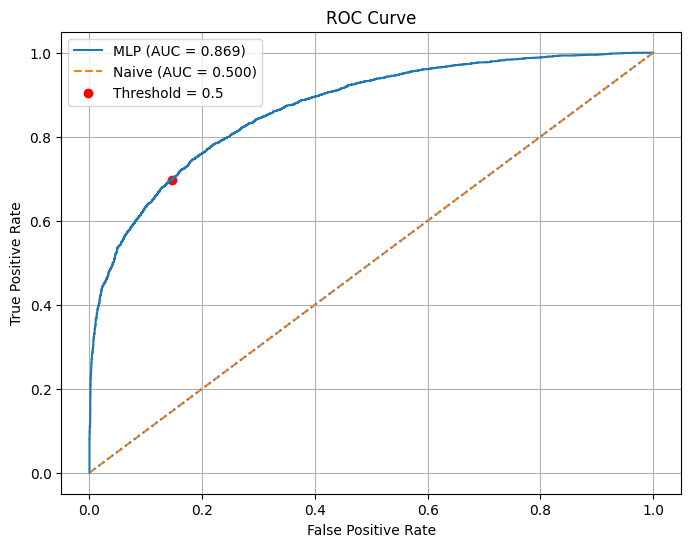

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.dummy import DummyClassifier
import matplotlib.pyplot as plt

y_proba = best_model.predict_proba(X_test_s)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_s, y_train)
dummy_proba = dummy.predict_proba(X_test_s)[:, 1]
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_proba)
auc_dummy = roc_auc_score(y_test, dummy_proba)

threshold_idx = np.argmin(np.abs(thresholds - 0.5))
threshold_point = (fpr[threshold_idx], tpr[threshold_idx])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"MLP (AUC = {auc:.3f})")
plt.plot(fpr_dummy, tpr_dummy, label=f"Naive (AUC = {auc_dummy:.3f})", linestyle='--')
plt.scatter(*threshold_point, color='red', label='Threshold = 0.5')
plt.plot([0, 1], [0, 1], linestyle=':', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


## Confusion Matrix

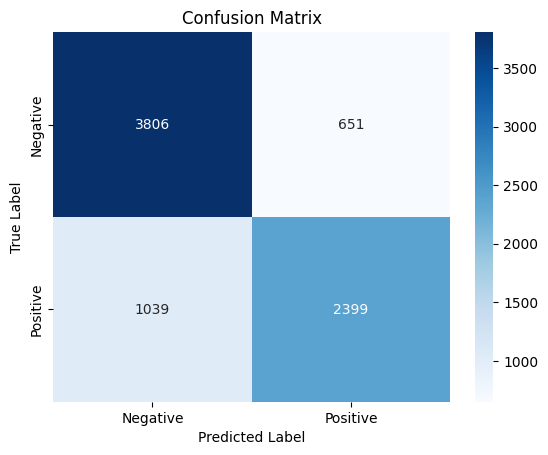

In [ ]:
import seaborn as sns

y_pred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


# Improvments


## Feature addition using deep-learning

new dataset from previous assigment with additions.....


In [ ]:
df_with_latent = pd.read_csv("https://raw.githubusercontent.com/AniShpiz/ML1/refs/heads/main/dataset_sentiment_with_latent.csv")

In [ ]:
# preform a train test split
from sklearn.model_selection import train_test_split

X = df_with_latent.drop(columns=['sentiment_numeric'])
y = df_with_latent['sentiment_numeric']

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.2, random_state=42) # 80 / 20 split
print("Train label percentages\n-----------\n", (pd.value_counts(y_train)/y_train.shape[0])*100)
print("\nTest label percentages\n-----------\n", pd.value_counts(y_test)/y_test.shape[0]*100)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

best_model = MLPClassifier(activation='logistic', hidden_layer_sizes=(150,), random_state=42)

best_model.fit(X_train_s, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test_s)

val_accuracy = accuracy_score(y_test, y_pred)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")


## Trying new model with Early Stopping mechanisem

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(150, activation='relu', input_shape=(X_train_s.shape[1],)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC()])

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_s, y_train, validation_data=(X_test_s, y_test),
                    epochs=100, batch_size=16, callbacks=[early_stop], verbose=1)


# Evaluate
results = model.evaluate(X_test_s, y_test)
print(f"Validation Accuracy: {results[1]*100:.2f}%")
print(f"Validation AUC: {results[2]:.3f}")